In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KDTree
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.stats import friedmanchisquare, wilcoxon



In [2]:
root_path = Path("/mnt/jwh83-data/Confetti")
output_dir = root_path / "output"

# HubMAP (ground truth)
HUBMAP_H5AD = output_dir / "HuBMAP_Yang_annotate.h5ad"

# Model outputs (ignore Nature)
MODEL_H5ADS = {
    "Mesmer":     output_dir / "Channel_feature" / "Merged" / "mesmer_leiden_prelim.h5ad",
    "Cellpose":   output_dir / "Channel_feature" / "Merged" / "cellpose_old_update3_leiden_prelim.h5ad",
    "CellposeSAM":output_dir / "Channel_feature" / "Merged" / "cellposeSAM_leiden_prelim.h5ad",
    "MicroSAM":   output_dir / "Channel_feature" / "Merged" / "microSAM_leiden_prelim.h5ad",
    "CellSAM":    output_dir / "Channel_feature" / "Merged" / "cellSAM_2_update_leiden_prelim.h5ad",
    "InstanSeg":  output_dir / "Channel_feature" / "Merged" / "instanseg_leiden_prelim.h5ad",
}

In [3]:
REGION_COL = "sample_ID"   # from your notebook
X_COL = "x"
Y_COL = "y"

# NN matching threshold (pixels)
MAX_DIST = 5.0

# Mutual NN enforcement (slower; stricter matches)
ENFORCE_MUTUAL = False

# Output directory for plots
PLOT_DIR = Path("hubmap_vs_models_plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)


In [4]:
def pick_first_existing(columns, candidates, required=True, name="column"):
    for c in candidates:
        if c in columns:
            return c
    if required:
        raise KeyError(f"Could not find {name}. Tried: {candidates}")
    return None

def detect_label_col(adata, prefer=("prelim_cell_type_mapped", "prelim_cell_type", "cell_type_update", "cell_type", "Cell Type")):
    return pick_first_existing(adata.obs.columns, list(prefer), required=True, name="label column")

def detect_cluster_col(adata, prefer_prefix=("leiden",), fallbacks=("cluster", "clusters")):
    cols = list(adata.obs.columns)
    # Prefer anything that starts with "leiden"
    for p in prefer_prefix:
        hits = [c for c in cols if str(c).startswith(p)]
        if hits:
            # choose the shortest name (usually plain "leiden")
            hits_sorted = sorted(hits, key=lambda s: (len(s), s))
            return hits_sorted[0]
    # fallback heuristics
    for f in fallbacks:
        hits = [c for c in cols if f in str(c).lower()]
        if hits:
            hits_sorted = sorted(hits, key=lambda s: (len(s), s))
            return hits_sorted[0]
    raise KeyError("Could not detect a clustering column (expected something like 'leiden').")

def ensure_required_obs(adata, required_cols):
    missing = [c for c in required_cols if c not in adata.obs.columns]
    if missing:
        raise KeyError(f"Missing required .obs columns: {missing}")


In [5]:
import anndata

adata_hub = anndata.read_h5ad(HUBMAP_H5AD)
ensure_required_obs(adata_hub, [REGION_COL, X_COL, Y_COL])

hub_label_col = detect_label_col(adata_hub)

# Load model adatas
model_adatas = {}
model_cluster_cols = {}
model_label_cols = {}

for name, fp in MODEL_H5ADS.items():
    ad = anndata.read_h5ad(fp)
    ensure_required_obs(ad, [REGION_COL, X_COL, Y_COL])
    model_adatas[name] = ad
    model_cluster_cols[name] = detect_cluster_col(ad)
    # model label col is optional; we mostly use hubmap labels as GT
    try:
        model_label_cols[name] = detect_label_col(ad)
    except Exception:
        model_label_cols[name] = None

print("HubMAP label column:", hub_label_col)
print("Detected clustering columns:")
for k, v in model_cluster_cols.items():
    print(f"  {k}: {v}")

/home/labuser/anaconda3/envs/rapids-env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


HubMAP label column: prelim_cell_type
Detected clustering columns:
  Mesmer: leiden
  Cellpose: leiden
  CellposeSAM: leiden
  MicroSAM: leiden
  CellSAM: leiden
  InstanSeg: leiden


In [6]:
def nn_match_per_region(
    adata_A, adata_B, region,
    region_col=REGION_COL,
    xA=X_COL, yA=Y_COL,
    xB=X_COL, yB=Y_COL,
    max_dist=MAX_DIST,
    enforce_mutual=ENFORCE_MUTUAL,
):
    """
    Match A -> B by NN in coordinate space within a max distance.
    Optionally keep only mutual NN pairs.
    Returns DataFrame with idx_A, idx_B, dist, region.
    """
    obsA = adata_A.obs
    obsB = adata_B.obs

    mA = (obsA[region_col].astype(str) == str(region))
    mB = (obsB[region_col].astype(str) == str(region))
    if not mA.any() or not mB.any():
        return pd.DataFrame(columns=["idx_A", "idx_B", "dist", "region"])

    A_inds = obsA.index[mA]
    B_inds = obsB.index[mB]

    A_xy = obsA.loc[A_inds, [xA, yA]].to_numpy(dtype=float)
    B_xy = obsB.loc[B_inds, [xB, yB]].to_numpy(dtype=float)

    # drop NaNs
    A_ok = ~np.isnan(A_xy).any(axis=1)
    B_ok = ~np.isnan(B_xy).any(axis=1)
    A_inds = A_inds[A_ok]
    B_inds = B_inds[B_ok]
    A_xy = A_xy[A_ok]
    B_xy = B_xy[B_ok]

    if len(A_xy) == 0 or len(B_xy) == 0:
        return pd.DataFrame(columns=["idx_A", "idx_B", "dist", "region"])

    tree_B = KDTree(B_xy)
    dAB, nnAB = tree_B.query(A_xy, k=1)
    dAB = dAB.ravel()
    nnAB = nnAB.ravel()

    keep = dAB <= max_dist
    if keep.sum() == 0:
        return pd.DataFrame(columns=["idx_A", "idx_B", "dist", "region"])

    matched = pd.DataFrame({
        "idx_A": A_inds[keep].to_numpy(),
        "idx_B": B_inds[nnAB[keep]].to_numpy(),
        "dist": dAB[keep],
        "region": str(region),
    })

    if enforce_mutual:
        # B -> A
        tree_A = KDTree(A_xy)
        dBA, nnBA = tree_A.query(B_xy, k=1)
        dBA = dBA.ravel()
        nnBA = nnBA.ravel()

        # map obs indices to positional indices
        A_pos = pd.Series(np.arange(len(A_inds)), index=A_inds)
        B_pos = pd.Series(np.arange(len(B_inds)), index=B_inds)

        apos = A_pos.loc[matched["idx_A"]].to_numpy()
        bpos = B_pos.loc[matched["idx_B"]].to_numpy()

        is_mutual = (nnBA[bpos] == apos) & (matched["dist"].to_numpy() <= max_dist)
        matched = matched.loc[is_mutual].reset_index(drop=True)

    return matched


In [7]:
def purity_score(cluster_labels, gt_labels):
    """
    Purity = sum_c max_k count(c,k) / N
    """
    df = pd.DataFrame({"c": cluster_labels, "g": gt_labels}).dropna()
    if df.empty:
        return np.nan
    ct = pd.crosstab(df["c"], df["g"])
    return (ct.max(axis=1).sum() / ct.values.sum()) if ct.values.sum() > 0 else np.nan

def cluster_level_f1(cluster_labels, gt_labels, average="macro"):
    """
    Your cluster-level F1:
    - For each cluster, assign predicted label = majority HubMAP label in that cluster.
    - Treat the cluster as predicting that label for its members.
    - For each cluster, compute F1 for that label:
        tp = #(cluster & label)
        fp = #(cluster & not label)
        fn = #(not cluster & label)
      F1 = 2tp / (2tp + fp + fn)
    - average:
        - "macro": mean over clusters
        - "weighted": weighted by cluster size
    """
    df = pd.DataFrame({"c": cluster_labels, "g": gt_labels}).dropna()
    if df.empty:
        return np.nan

    # totals per ground-truth label
    gt_totals = df["g"].value_counts()

    f1s = []
    weights = []

    for c, sub in df.groupby("c"):
        # majority label within cluster
        maj = sub["g"].value_counts().idxmax()
        tp = int((sub["g"] == maj).sum())
        fp = int((sub["g"] != maj).sum())
        fn = int(gt_totals.get(maj, 0) - tp)
        denom = (2 * tp + fp + fn)
        f1 = (2 * tp / denom) if denom > 0 else np.nan

        f1s.append(f1)
        weights.append(len(sub))

    f1s = np.array(f1s, dtype=float)
    weights = np.array(weights, dtype=float)

    if average == "macro":
        return np.nanmean(f1s)
    if average == "weighted":
        if np.nansum(weights) == 0:
            return np.nan
        # weighted mean ignoring NaNs
        ok = ~np.isnan(f1s)
        return np.sum(f1s[ok] * weights[ok]) / np.sum(weights[ok])
    raise ValueError("average must be 'macro' or 'weighted'")

In [8]:
def compute_method_metrics_vs_hubmap(method_name, adata_method):
    cluster_col = model_cluster_cols[method_name]
    # shared regions
    regions = sorted(set(adata_method.obs[REGION_COL].dropna().astype(str)).intersection(
                     set(adata_hub.obs[REGION_COL].dropna().astype(str))))

    rows = []
    all_dists = []

    for r in regions:
        # match method -> hubmap
        matches = nn_match_per_region(adata_method, adata_hub, r)

        # counts (all cells in region, regardless of matching)
        n_method_region = int((adata_method.obs[REGION_COL].astype(str) == r).sum())
        n_hub_region = int((adata_hub.obs[REGION_COL].astype(str) == r).sum())

        if len(matches) == 0:
            rows.append({
                "method": method_name,
                "region": r,
                "n_matched": 0,
                "match_rate_method": 0.0,
                "match_rate_hubmap": 0.0,
                "cellcount_method": n_method_region,
                "cellcount_hubmap": n_hub_region,
                "cellcount_diff": n_method_region - n_hub_region,
                "purity": np.nan,
                "ari": np.nan,
                "nmi": np.nan,
                "f1_macro": np.nan,
                "f1_weighted": np.nan,
            })
            continue

        all_dists.append(matches["dist"].to_numpy())

        # aligned labels
        clusters = adata_method.obs.loc[matches["idx_A"], cluster_col].astype(str).to_numpy()
        gt = adata_hub.obs.loc[matches["idx_B"], hub_label_col].astype(str).to_numpy()

        # metrics
        purity = purity_score(clusters, gt)

        # For ARI/NMI, factorize to int codes (these operate on partitions)
        c_codes, _ = pd.factorize(clusters)
        g_codes, _ = pd.factorize(gt)
        ari = adjusted_rand_score(g_codes, c_codes)
        nmi = normalized_mutual_info_score(g_codes, c_codes)

        f1m = cluster_level_f1(clusters, gt, average="macro")
        f1w = cluster_level_f1(clusters, gt, average="weighted")

        n_matched = len(matches)
        rows.append({
            "method": method_name,
            "region": r,
            "n_matched": n_matched,
            "match_rate_method": n_matched / n_method_region if n_method_region > 0 else np.nan,
            "match_rate_hubmap": n_matched / n_hub_region if n_hub_region > 0 else np.nan,
            "cellcount_method": n_method_region,
            "cellcount_hubmap": n_hub_region,
            "cellcount_diff": n_method_region - n_hub_region,
            "purity": purity,
            "ari": ari,
            "nmi": nmi,
            "f1_macro": f1m,
            "f1_weighted": f1w,
        })

    dist_vec = np.concatenate(all_dists) if len(all_dists) else np.array([])
    return pd.DataFrame(rows), dist_vec

all_metrics = []
dist_by_method = {}

for name, ad in model_adatas.items():
    dfm, dists = compute_method_metrics_vs_hubmap(name, ad)
    all_metrics.append(dfm)
    dist_by_method[name] = dists

metrics_df = pd.concat(all_metrics, ignore_index=True)

# Save a tidy table
metrics_df.to_csv(PLOT_DIR / "hubmap_vs_models_metrics_by_region.csv", index=False)
print("Saved metrics table to:", PLOT_DIR / "hubmap_vs_models_metrics_by_region.csv")

print("\nPreview:")
print(metrics_df.head())



Saved metrics table to: hubmap_vs_models_plots/hubmap_vs_models_metrics_by_region.csv

Preview:
   method      region  n_matched  match_rate_method  match_rate_hubmap  \
0  Mesmer  B004-A-004      15914           0.675926           0.683973   
1  Mesmer  B004-A-008      15867           0.632984           0.618548   
2  Mesmer  B004-A-104      20190           0.651774           0.609749   
3  Mesmer  B004-A-204      10759           0.642022           0.574702   
4  Mesmer  B004-A-304      14503           0.688684           0.640139   

   cellcount_method  cellcount_hubmap  cellcount_diff    purity       ari  \
0             23544             23267             277  0.690398  0.564005   
1             25067             25652            -585  0.524296  0.272183   
2             30977             33112           -2135  0.516493  0.204734   
3             16758             18721           -1963  0.581746  0.316825   
4             21059             22656           -1597  0.629042  0.360149 

Saved: hubmap_vs_models_plots/match_distance_histograms.png


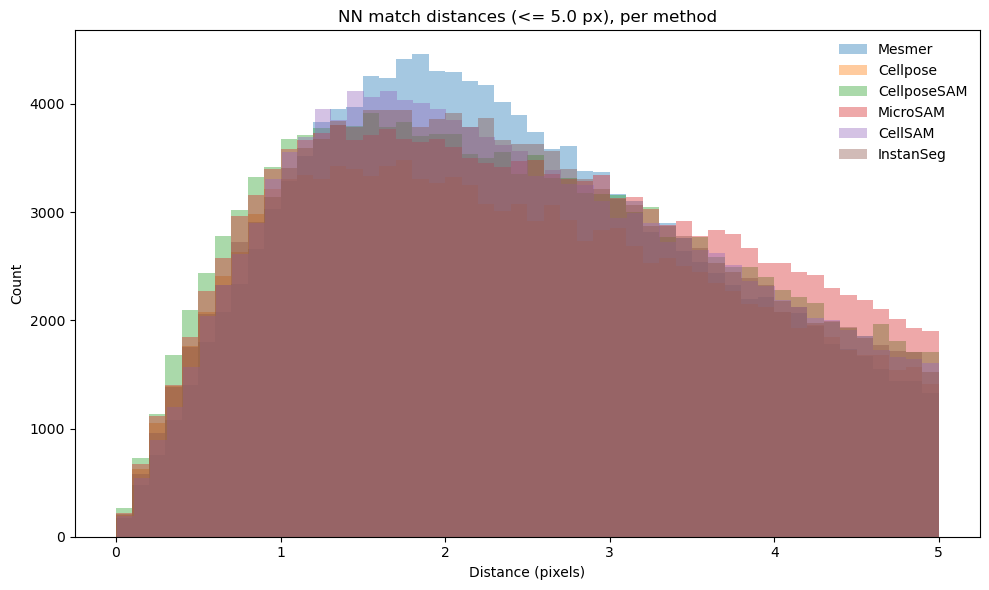

Saved: hubmap_vs_models_plots/boxplot_f1_weighted.png


/tmp/ipykernel_2886478/432215615.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


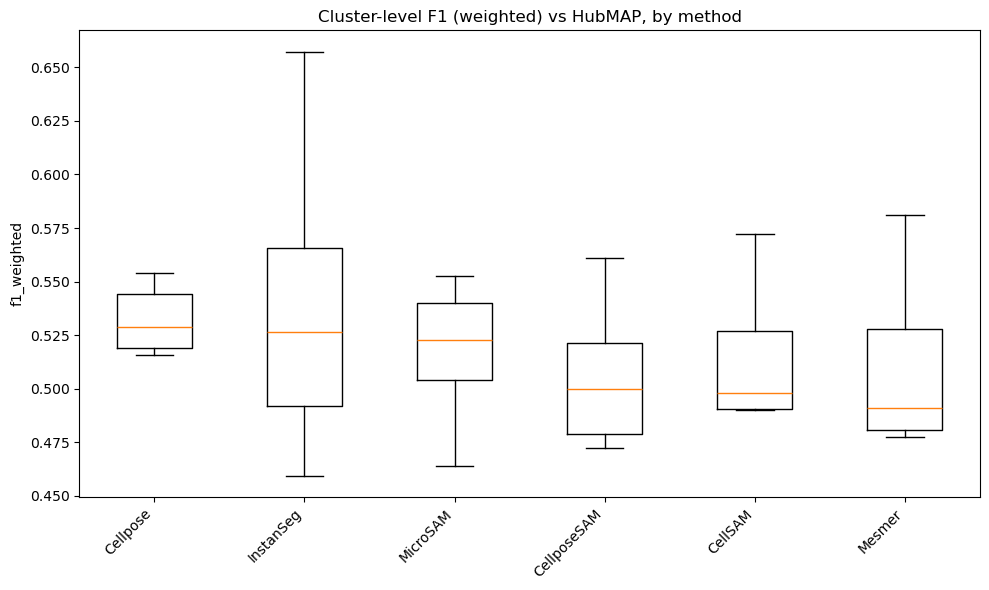

/tmp/ipykernel_2886478/432215615.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


Saved: hubmap_vs_models_plots/boxplot_f1_macro.png


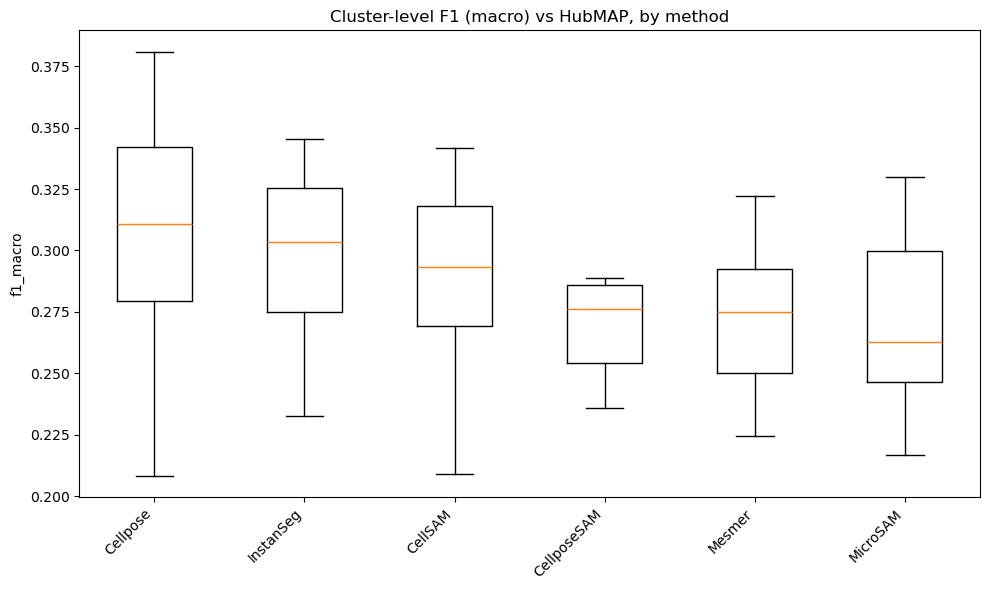

/tmp/ipykernel_2886478/432215615.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


Saved: hubmap_vs_models_plots/boxplot_purity.png


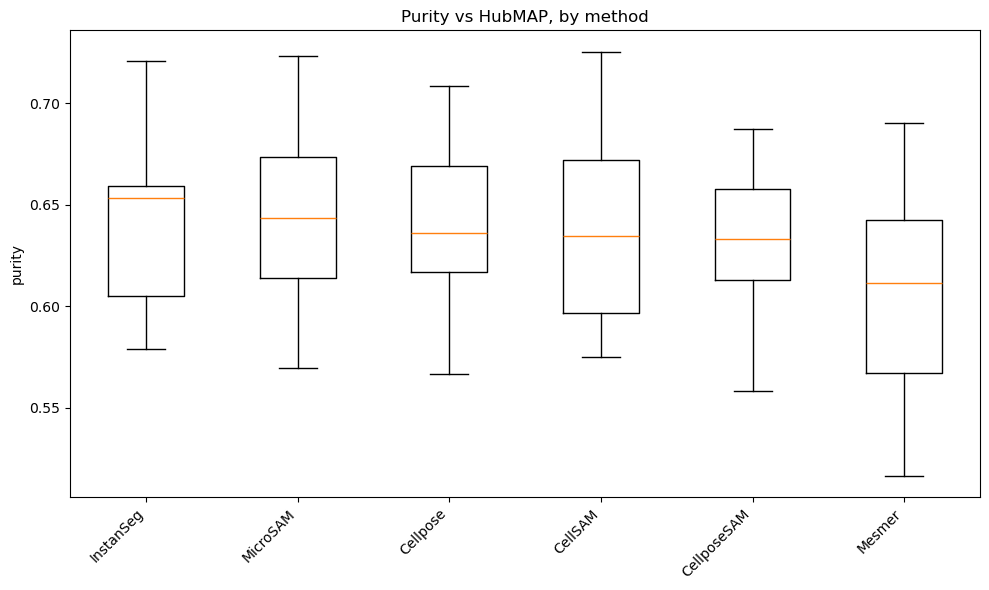

/tmp/ipykernel_2886478/432215615.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


Saved: hubmap_vs_models_plots/boxplot_ari.png


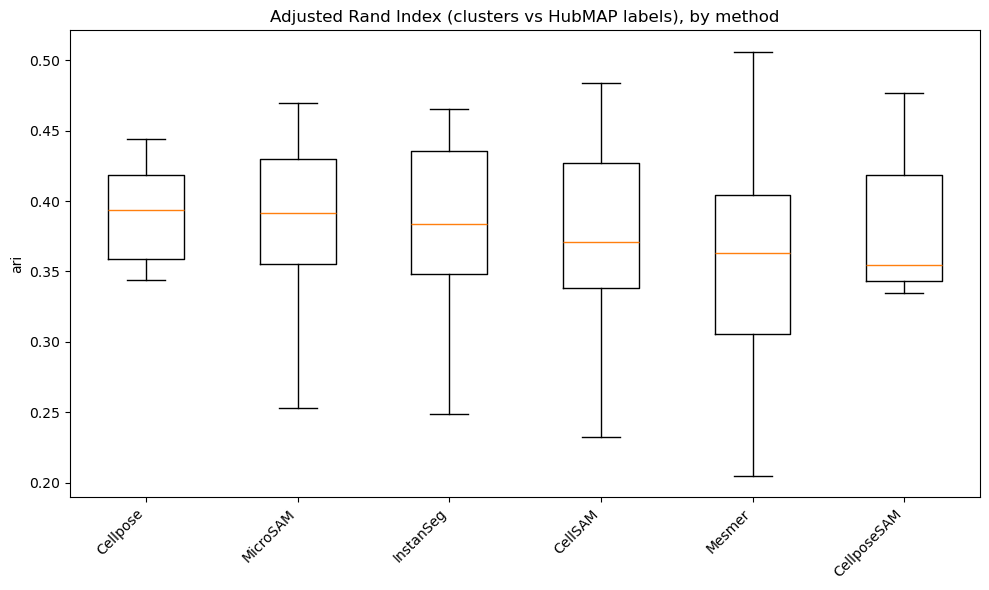

/tmp/ipykernel_2886478/432215615.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


Saved: hubmap_vs_models_plots/boxplot_nmi.png


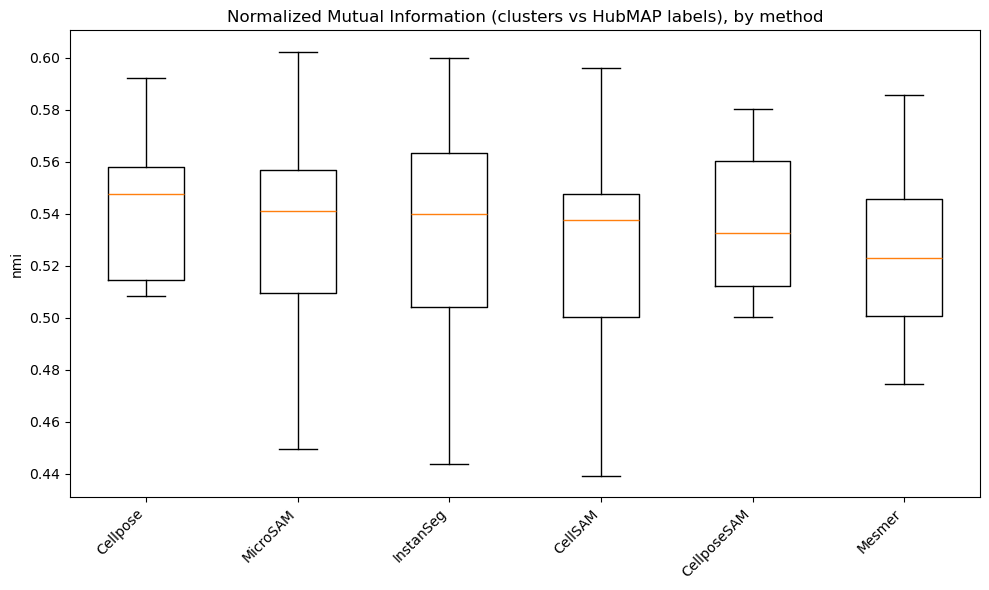

Saved: hubmap_vs_models_plots/cellcount_scatter.png


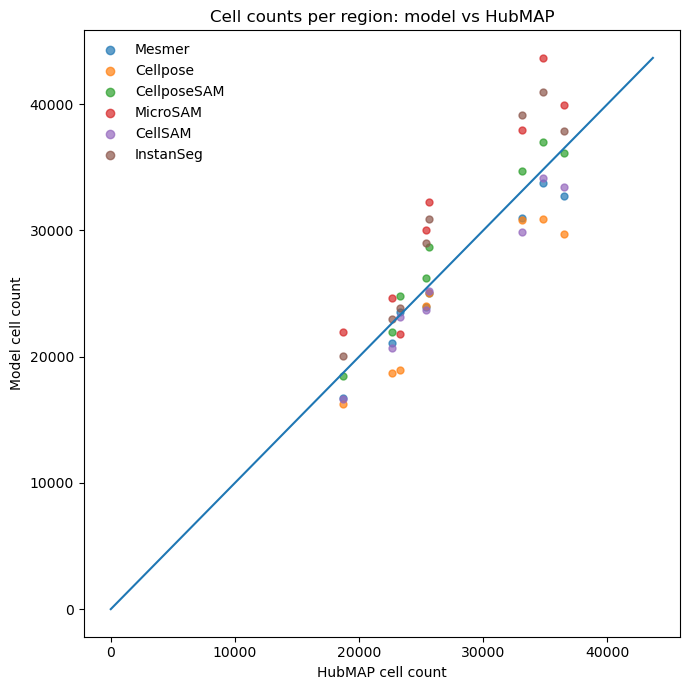

/tmp/ipykernel_2886478/432215615.py:79: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(ct_pct.values, aspect="auto")
/tmp/ipykernel_2886478/432215615.py:79: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(ct_pct.values, aspect="auto")


Saved: hubmap_vs_models_plots/heatmap_Mesmer_region_B004-A-004.png


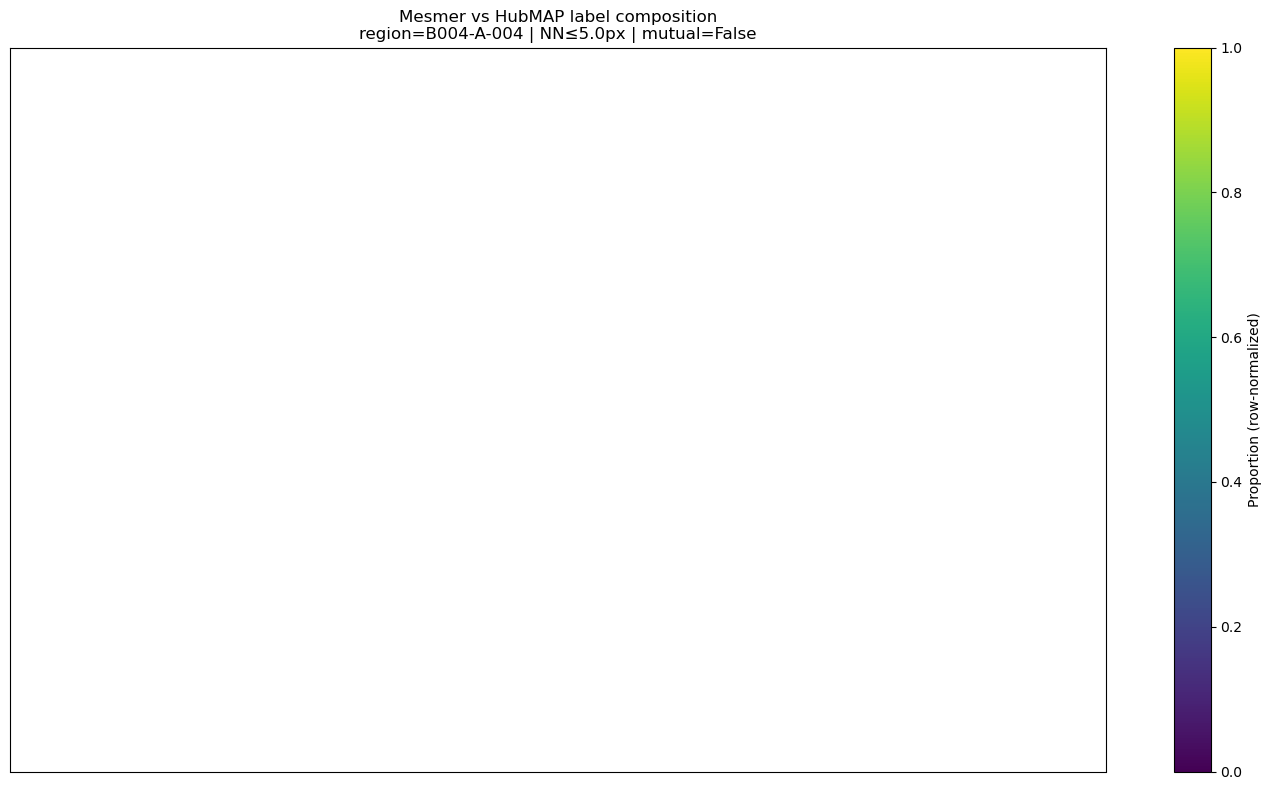

In [9]:
def savefig(name):
    fp = PLOT_DIR / name
    plt.savefig(fp, dpi=300, bbox_inches="tight")
    print("Saved:", fp)

# 7a) Matching distance histograms
plt.figure(figsize=(10, 6))
for method, dists in dist_by_method.items():
    if len(dists) == 0:
        continue
    plt.hist(dists, bins=50, alpha=0.4, label=method)
plt.title(f"NN match distances (<= {MAX_DIST} px), per method")
plt.xlabel("Distance (pixels)")
plt.ylabel("Count")
plt.legend(frameon=False)
plt.tight_layout()
savefig("match_distance_histograms.png")
plt.show()

# 7b) Boxplots of key metrics
def boxplot_metric(df, metric, title):
    plot_df = df.dropna(subset=[metric]).copy()
    if plot_df.empty:
        print(f"No data for {metric}")
        return
    order = (plot_df.groupby("method")[metric].median().sort_values(ascending=False).index.tolist())

    plt.figure(figsize=(10, 6))
    data = [plot_df.loc[plot_df["method"] == m, metric].to_numpy() for m in order]
    plt.boxplot(data, labels=order, showfliers=False)
    plt.title(title)
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    savefig(f"boxplot_{metric}.png")
    plt.show()

boxplot_metric(metrics_df, "f1_weighted", "Cluster-level F1 (weighted) vs HubMAP, by method")
boxplot_metric(metrics_df, "f1_macro", "Cluster-level F1 (macro) vs HubMAP, by method")
boxplot_metric(metrics_df, "purity", "Purity vs HubMAP, by method")
boxplot_metric(metrics_df, "ari", "Adjusted Rand Index (clusters vs HubMAP labels), by method")
boxplot_metric(metrics_df, "nmi", "Normalized Mutual Information (clusters vs HubMAP labels), by method")

# 7c) Cell count scatter by region (model vs HubMAP)
plt.figure(figsize=(7, 7))
for method in metrics_df["method"].unique():
    sub = metrics_df[metrics_df["method"] == method]
    plt.scatter(sub["cellcount_hubmap"], sub["cellcount_method"], s=25, alpha=0.7, label=method)
mx = max(metrics_df["cellcount_hubmap"].max(), metrics_df["cellcount_method"].max())
plt.plot([0, mx], [0, mx])
plt.title("Cell counts per region: model vs HubMAP")
plt.xlabel("HubMAP cell count")
plt.ylabel("Model cell count")
plt.legend(frameon=False, markerscale=1.2)
plt.tight_layout()
savefig("cellcount_scatter.png")
plt.show()

# 7d) Heatmap example: cluster vs HubMAP label for one method/region
def plot_cluster_gt_heatmap(method_name, region):
    ad = model_adatas[method_name]
    cl_col = model_cluster_cols[method_name]

    matches = nn_match_per_region(ad, adata_hub, region)
    if len(matches) == 0:
        print(f"No matches for {method_name} region={region}")
        return

    clusters = ad.obs.loc[matches["idx_A"], cl_col].astype(str)
    gt = adata_hub.obs.loc[matches["idx_B"], hub_label_col].astype(str)

    ct = pd.crosstab(clusters, gt)

    # normalize rows -> within cluster composition
    row_sums = ct.sum(axis=1).replace(0, np.nan)
    ct_pct = ct.div(row_sums, axis=0).fillna(0.0)

    plt.figure(figsize=(14, 8))
    plt.imshow(ct_pct.values, aspect="auto")
    plt.colorbar(label="Proportion (row-normalized)")
    plt.title(f"{method_name} vs HubMAP label composition\nregion={region} | NN≤{MAX_DIST}px | mutual={ENFORCE_MUTUAL}")
    plt.xticks(ticks=np.arange(ct_pct.shape[1]), labels=ct_pct.columns, rotation=45, ha="right")
    plt.yticks(ticks=np.arange(ct_pct.shape[0]), labels=ct_pct.index)
    plt.tight_layout()
    savefig(f"heatmap_{method_name}_region_{region}.png")
    plt.show()

# choose a region that exists for all (first common)
common_regions = None
for m in model_adatas:
    regs = set(model_adatas[m].obs[REGION_COL].dropna().astype(str).unique())
    hub_regs = set(adata_hub.obs[REGION_COL].dropna().astype(str).unique())
    regs = regs.intersection(hub_regs)
    common_regions = regs if common_regions is None else common_regions.intersection(regs)

common_regions = sorted(common_regions) if common_regions else []
if common_regions:
    example_region = common_regions[0]
    plot_cluster_gt_heatmap("Mesmer", example_region)
else:
    print("No common regions found across all methods and HubMAP.")


In [10]:
def holm_adjust(pvals):
    """
    Holm step-down adjustment. Returns adjusted p-values in original order.
    """
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)

    # Holm: p_(i) * (m - i)
    prev = 0.0
    for rank, idx in enumerate(order):
        factor = (m - rank)
        val = pvals[idx] * factor
        val = max(val, prev)  # ensure monotone non-decreasing in sorted order
        prev = val
        adj[idx] = min(val, 1.0)

    return adj

def friedman_and_posthoc(df, metric):
    """
    Friedman across methods using regions as blocks (requires complete cases).
    Then paired Wilcoxon posthoc (Holm).
    """
    pivot = df.pivot_table(index="region", columns="method", values=metric, aggfunc="mean")
    pivot = pivot.dropna(axis=0, how="any")  # complete-case regions

    if pivot.shape[0] < 3 or pivot.shape[1] < 2:
        print(f"[{metric}] Not enough complete paired data for Friedman (regions={pivot.shape[0]}, methods={pivot.shape[1]}).")
        return None, None, None

    methods = list(pivot.columns)
    arrays = [pivot[m].to_numpy() for m in methods]

    stat, p = friedmanchisquare(*arrays)
    friedman_res = {"metric": metric, "n_regions": pivot.shape[0], "methods": methods, "chi2": stat, "p": p}

    # posthoc Wilcoxon (paired, two-sided)
    pairs = []
    pvals = []
    for i in range(len(methods)):
        for j in range(i + 1, len(methods)):
            a = pivot[methods[i]].to_numpy()
            b = pivot[methods[j]].to_numpy()
            # if all differences are zero, wilcoxon can fail; handle safely
            if np.allclose(a, b, equal_nan=False):
                w_p = 1.0
            else:
                try:
                    _, w_p = wilcoxon(a, b, zero_method="wilcox", alternative="two-sided")
                except ValueError:
                    w_p = np.nan
            pairs.append((methods[i], methods[j]))
            pvals.append(w_p)

    p_adj = holm_adjust(pvals)

    posthoc = pd.DataFrame({
        "metric": metric,
        "A": [a for a, b in pairs],
        "B": [b for a, b in pairs],
        "p_value": pvals,
        "p_adj_holm": p_adj,
        "reject_0.05": (p_adj < 0.05),
        "median_diff(A-B)": [
            np.nanmedian(pivot[a] - pivot[b]) for a, b in pairs
        ],
    }).sort_values("p_adj_holm")

    return friedman_res, posthoc, pivot

In [11]:
STAT_METRICS = ["f1_weighted", "f1_macro", "purity", "ari", "nmi", "cellcount_diff", "match_rate_method"]

friedman_results = []
posthoc_tables = {}

for metric in STAT_METRICS:
    fr, ph, pv = friedman_and_posthoc(metrics_df, metric)
    if fr is None:
        continue
    friedman_results.append(fr)
    posthoc_tables[metric] = ph

friedman_df = pd.DataFrame(friedman_results).sort_values("p")
friedman_df.to_csv(PLOT_DIR / "friedman_summary.csv", index=False)
print("\nSaved:", PLOT_DIR / "friedman_summary.csv")
print("\nFriedman summary:")
print(friedman_df)

# Save posthoc tables
for metric, ph in posthoc_tables.items():
    out = PLOT_DIR / f"posthoc_wilcoxon_holm_{metric}.csv"
    ph.to_csv(out, index=False)
    print("Saved:", out)

# Quick print top differences
for metric, ph in posthoc_tables.items():
    print(f"\nPosthoc (top 10) for {metric}:")
    print(ph.head(10).to_string(index=False))


# ----------------------------
# 9) Simple "closest to HubMAP" ranking
# ----------------------------
# Rank by median f1_weighted across regions
ranking = (metrics_df.groupby("method")["f1_weighted"]
           .median()
           .sort_values(ascending=False)
           .reset_index()
           .rename(columns={"f1_weighted": "median_f1_weighted"}))

ranking.to_csv(PLOT_DIR / "method_ranking_by_median_f1_weighted.csv", index=False)
print("\nSaved:", PLOT_DIR / "method_ranking_by_median_f1_weighted.csv")
print("\nRanking by median weighted cluster-F1:")
print(ranking)


Saved: hubmap_vs_models_plots/friedman_summary.csv

Friedman summary:
              metric  n_regions  \
6  match_rate_method          8   
5     cellcount_diff          8   
1           f1_macro          8   
2             purity          8   
0        f1_weighted          8   
4                nmi          8   
3                ari          8   

                                             methods       chi2             p  
6  [CellSAM, Cellpose, CellposeSAM, InstanSeg, Me...  36.214286  8.605258e-07  
5  [CellSAM, Cellpose, CellposeSAM, InstanSeg, Me...  30.357143  1.254337e-05  
1  [CellSAM, Cellpose, CellposeSAM, InstanSeg, Me...  23.500000  2.707986e-04  
2  [CellSAM, Cellpose, CellposeSAM, InstanSeg, Me...  16.142857  6.447828e-03  
0  [CellSAM, Cellpose, CellposeSAM, InstanSeg, Me...  13.428571  1.967708e-02  
4  [CellSAM, Cellpose, CellposeSAM, InstanSeg, Me...   5.357143  3.738650e-01  
3  [CellSAM, Cellpose, CellposeSAM, InstanSeg, Me...   4.785714  4.425878e-01  
Saved: h